In [1]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input,Lambda,UpSampling2D,Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,Flatten,BatchNormalization, Activation,ConvLSTM2D,TimeDistributed, GlobalAveragePooling2D, GlobalMaxPooling2D, Add, multiply,Reshape,RepeatVector,LayerNormalization
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
from tensorflow.keras.callbacks         import LearningRateScheduler,Callback,CSVLogger


from sklearn.metrics                    import mean_squared_error,r2_score,mean_absolute_error

import sys
import os
import numpy as np
import math
import time
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

2025-06-30 00:55:23.860095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751259323.874126   82484 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751259323.878218   82484 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751259323.888611   82484 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751259323.888626   82484 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751259323.888627   82484 computation_placer.cc:177] computation placer alr

In [2]:
directory= os.path.abspath('/home/ppgi/Trabajo/predicting-flow-patterns')
sys.path.append(directory)
from NpyDataGenerator import DataGenerator
from tools import *

### 1. Dataset Creation and Loading

In [3]:
#directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_Masked'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

nbatch = 10

In [4]:
g_train = sorted(glob.glob(os.path.join(gtrain, "*.npy")))
g_test  = sorted(glob.glob(os.path.join(gtest, "*.npy")))
g_val   = sorted(glob.glob(os.path.join(gval, "*.npy")))

p_train = sorted(glob.glob(os.path.join(ptrain, "*.npy")))
p_test  = sorted(glob.glob(os.path.join(ptest, "*.npy")))
p_val   = sorted(glob.glob(os.path.join(pval, "*.npy")))

v_train = sorted(glob.glob(os.path.join(vtrain, "*.npy")))
v_test  = sorted(glob.glob(os.path.join(vtest, "*.npy")))
v_val   = sorted(glob.glob(os.path.join(vval, "*.npy")))

vx_train = sorted(glob.glob(os.path.join(vxtrain, "*.npy")))
vx_test  = sorted(glob.glob(os.path.join(vxtest, "*.npy")))
vx_val   = sorted(glob.glob(os.path.join(vxval, "*.npy")))

vy_train = sorted(glob.glob(os.path.join(vytrain, "*.npy")))
vy_test  = sorted(glob.glob(os.path.join(vytest, "*.npy")))
vy_val   = sorted(glob.glob(os.path.join(vyval, "*.npy")))

train_ds=DataGenerator(g_train,p_train,v_train,vx_train,vy_train)
test_ds=DataGenerator(g_test,p_test,v_test,vx_test,vy_test)
val_ds=DataGenerator(g_val,p_val,v_val,vx_val,vy_val)

### 2. Hyperparameters

In [5]:
num_epochs    =200  #200
patience      =15     # How long to wait after last time validation loss improved #15
LR            =0.001

# Model name
model_names=['Conv-LSTM-encoder-decoder']
NamesKeras=['Arch_1.keras','Arch_2.keras','Arch_3.keras','Arch_4.keras','Arch_5.keras']
model_name    =model_names[0]
#save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1


type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
DECAY_RATE=0.04
#name_logger='conv-lstm-training-log'

### 3. Exponential Decay Learning Rate

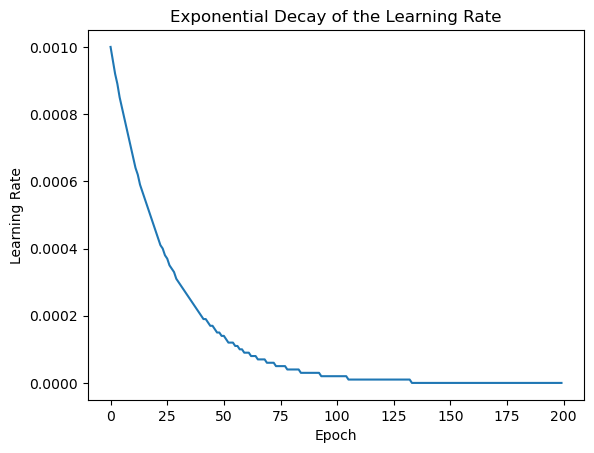

In [6]:
def exponential_decay(epoch,lr_ini=LR,decay_rate=DECAY_RATE,epochs=num_epochs):
    if epoch < epochs*0.001:
        return lr_ini
    else:
        return  lr_ini * np.exp(-decay_rate*epoch)
    
epochs = np.arange(num_epochs)
learning_rates = [round(exponential_decay(epoch),5) for epoch in epochs]


plt.plot(epochs, learning_rates, label="Learning Rate")
plt.title("Exponential Decay of the Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(False)
plt.show()  

### 4. Callbacks

In [7]:
lr_scheduler = LearningRateScheduler(lambda epoch: exponential_decay(epoch), verbose=1)
optimizer = Adam(learning_rate=LR)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Conv_LSTM_weights/Test1_Best_weights.weights.h5'
checkpoint_weight=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)
checkpoint_keras = tf.keras.callbacks.ModelCheckpoint(NamesKeras[0],save_best_only=True)
csv_logger = CSVLogger('training_log.csv', append=False)


I0000 00:00:1751259327.296102   82484 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2257 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [8]:
def make_model():
    
    image_input = Input((img_height, img_width, channel))
    reshaped_input = layers.Reshape((1,img_height, img_width, channel))(image_input)

    x1 = layers.ConvLSTM2D(filters=8, kernel_size=3, padding="same", return_sequences=True)(reshaped_input)
    x1 = layers.BatchNormalization()(x1)
    x2 = layers.ConvLSTM2D(filters=16, kernel_size=3, padding="same", return_sequences=True)(x1)
    x2 = layers.BatchNormalization()(x2)
    x3 = layers.ConvLSTM2D(filters=32, kernel_size=3, padding="same", return_sequences=True)(x2)
    x3= layers.BatchNormalization()(x3)
    
    bottleneck = layers.ConvLSTM2D(filters=64, kernel_size=3, padding="same", return_sequences=True)(x3)
    bottleneck = layers.BatchNormalization()(bottleneck)

    d1 = layers.ConvLSTM2D(filters=32, kernel_size=3, padding="same", return_sequences=True)(bottleneck)
    d1 = layers.Concatenate()([d1, x3])
    d1 = layers.BatchNormalization()(d1)

    d2 = layers.ConvLSTM2D(filters=16, kernel_size=3, padding="same", return_sequences=True)(d1)
    d2 = layers.Concatenate()([d2,x2])
    d2 = layers.BatchNormalization()(d2)

    d3 = layers.ConvLSTM2D(filters=8, kernel_size=3, padding="same", return_sequences=True)(d2)
    d3 = layers.Concatenate()([d3,x1])
    d3 = layers.BatchNormalization()(d3)

  
    temporal = layers.Conv3D(4, (1, 1,1), activation=f_activation_last,name='flows_output',padding="same")(d3)
    # construct model
    # Squeeze for removing temporal axis: (None, 1, 64, 256, 4) -> (None, 64, 256, 4)
    flows_out= layers.Lambda(lambda x: tf.squeeze(x, axis=1))(temporal)
  
    model =  keras.Model(inputs=image_input, outputs=[flows_out],name= model_name)
    
    model.summary()

  
    model.compile(optimizer=optimizer, 
              loss = 'mean_squared_error',
              
              metrics= ['mae', "root_mean_squared_error"] )

    return model  


### 5. Architecture

In [9]:
M=make_model()

Model: "Conv-LSTM-encoder-decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 256,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64,     │          0 │ input_layer[0][0] │
│                     │ 256, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 1, 64,     │      2,624 │ reshape[0][0]     │
│ (ConvLSTM2D)        │ 256, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1, 64,     │         32 │ conv_lstm2d[0][0] │
│ (BatchNormalizatio… │ 256, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_1       │ (None, 1, 64,     │     13,888 │ batch_normalizat… │
│ (ConvLSTM2D)        │ 256, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 64,     │         64 │ conv_lstm2d_1[0]… │
│ (BatchNormalizatio… │ 256, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_2       │ (None, 1, 64,     │     55,424 │ batch_normalizat… │
│ (ConvLSTM2D)        │ 256, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 64,     │        128 │ conv_lstm2d_2[0]… │
│ (BatchNormalizatio… │ 256, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_3       │ (None, 1, 64,     │    221,440 │ batch_normalizat… │
│ (ConvLSTM2D)        │ 256, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 64,     │        256 │ conv_lstm2d_3[0]… │
│ (BatchNormalizatio… │ 256, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_4       │ (None, 1, 64,     │    110,720 │ batch_normalizat… │
│ (ConvLSTM2D)        │ 256, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1, 64,     │          0 │ conv_lstm2d_4[0]… │
│ (Concatenate)       │ 256, 64)          │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 64,     │        256 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 256, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_5       │ (None, 1, 64,     │     46,144 │ batch_normalizat… │
│ (ConvLSTM2D)        │ 256, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1, 64,     │          0 │ conv_lstm2d_5[0]… │
│ (Concatenate)       │ 256, 32)          │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 64,     │        128 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 256, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_6       │ (None, 1, 64,     │     11,552 │ batch_normalizat

 Total params: 462,788 (1.77 MB)

 Trainable params: 462,324 (1.76 MB)

 Non-trainable params: 464 (1.81 KB)

### 6. Parameters Number

In [10]:
params_simple = M.count_params()
print('Parameters Number: ', params_simple)

Parameters Number:  462788


### 7. Fitting

In [11]:
print("Starting training")
start_time_for_fit = time.time()
history = M.fit(train_ds,epochs=num_epochs,validation_data = val_ds,
                callbacks=[lr_scheduler,early_stopping,checkpoint_weight,checkpoint_keras,csv_logger])
end_time_for_fit = time.time()
Training_time = end_time_for_fit - start_time_for_fit
print(f"TRAINING TIME IN  {Training_time:.4f} segundos.")
    

Starting training

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/200


/home/ppgi/miniconda3/envs/newEnviroment/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1751259335.798325   82573 service.cc:152] XLA service 0x563b7db705c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751259335.798341   82573 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-06-30 00:55:36.110829: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751259337.685713   82573 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-30 00:55:39.905156: I ex

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 431s 291ms/step - loss: 0.0181 - mae: 0.0787 - root_mean_squared_error: 0.1309 - val_loss: 0.0338 - val_mae: 0.1469 - val_root_mean_squared_error: 0.1837 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0009607894391523232.
Epoch 2/200
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 405s 289ms/step - loss: 0.0104 - mae: 0.0615 - root_mean_squared_error: 0.1019 - val_loss: 0.0131 - val_mae: 0.0834 - val_root_mean_squared_error: 0.1144 - learning_rate: 9.6079e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009231163463866358.
Epoch 3/200
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 407s 291ms/step - loss: 0.0088 - mae: 0.0565 - root_mean_squared_error: 0.0938 - val_loss: 0.0097 - val_mae: 0.0613 - val_root_mean_squared_error: 0.0987 - learning_rate: 9.2312e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0008869204367171575.
Epoch 4/200
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 407s 291ms/step - loss: 0.0087 - mae: 0.0561 - root_mean_s

### 8. Evaluation

In [12]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.6f}")

200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - loss: 0.0079 - mae: 0.0531 - root_mean_squared_error: 0.0887
Evaluation results:
loss: 0.007710
compile_metrics: 0.052709


### 9. Prediction

In [13]:
best_weights=save
M.load_weights(best_weights)

In [14]:
ytrue,ypred=predicting_error(test_ds,M)

*** Starting ***
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/

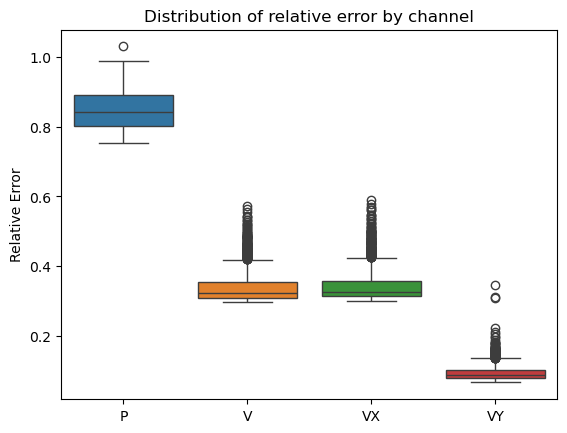

In [15]:
relative_error(ypred,ytrue)

In [16]:
metric_by_channels(ypred,ytrue)

p: MSE = 0.017161, MAE = 0.094194, RMSE =0.131001
v: MSE = 0.003684, MAE = 0.042599, RMSE =0.060699
vx: MSE = 0.003555, MAE = 0.042146, RMSE =0.059620
vy: MSE = 0.006501, MAE = 0.033701, RMSE =0.080628
MSE global: 0.007725
MAE global: 0.053160
MAE % global: 5.316018
RMSE global: 0.087894


### 10. Figures

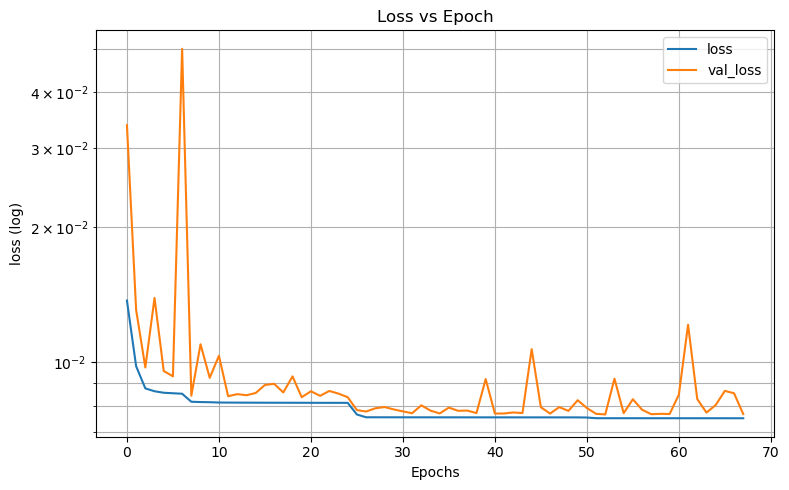

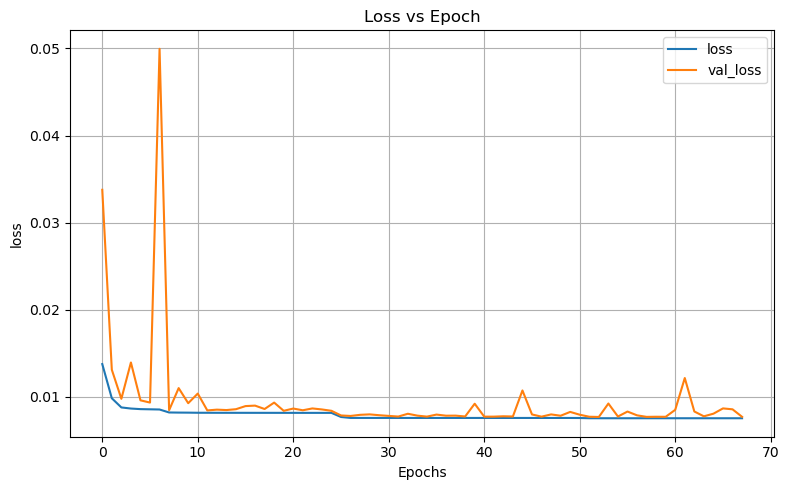

In [17]:
plot_model(history,'loss','val_loss',"Loss vs Epoch",True)

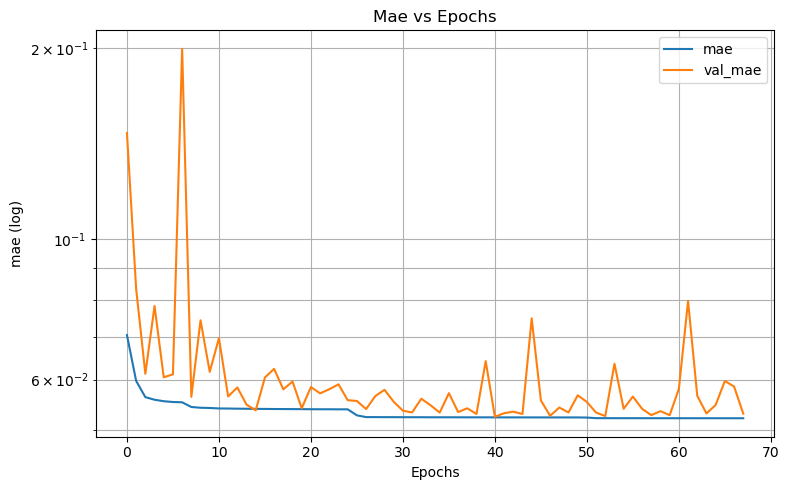

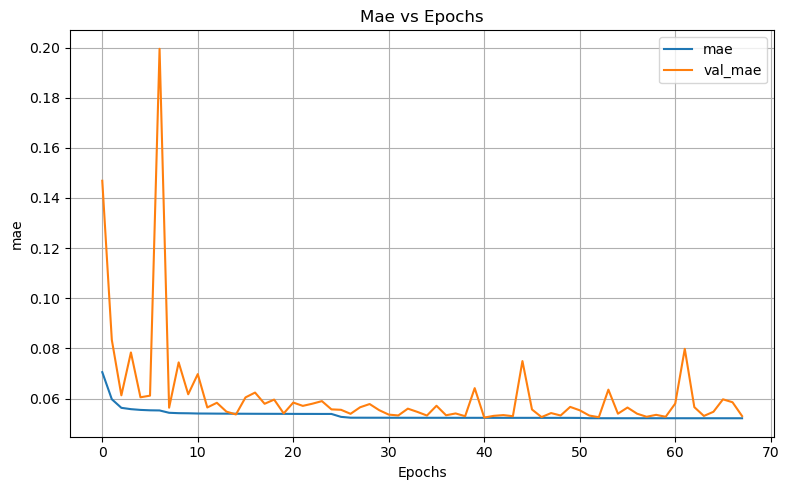

In [18]:
plot_model(history,'mae','val_mae',"Mae vs Epochs",True)

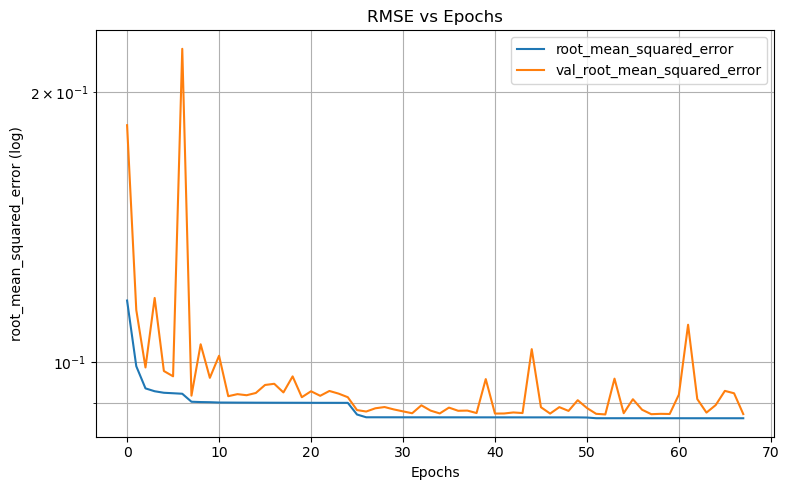

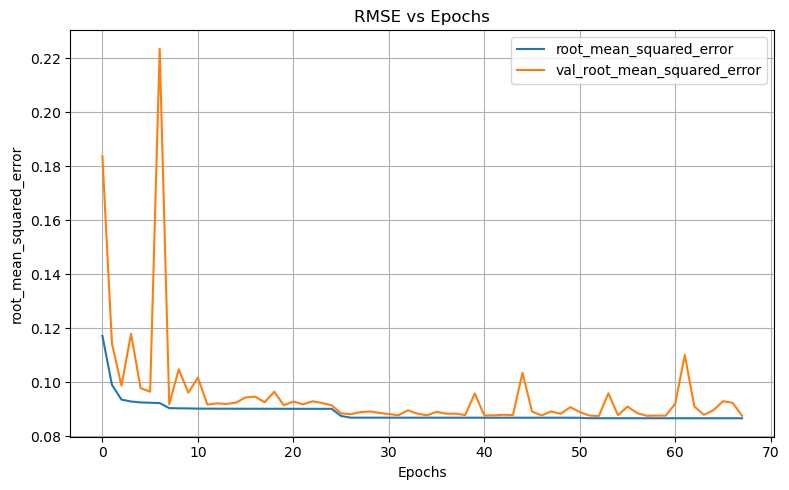

In [19]:
plot_model(history,'root_mean_squared_error','val_root_mean_squared_error',"RMSE vs Epochs",True)

### 11. Qualitative Visualization

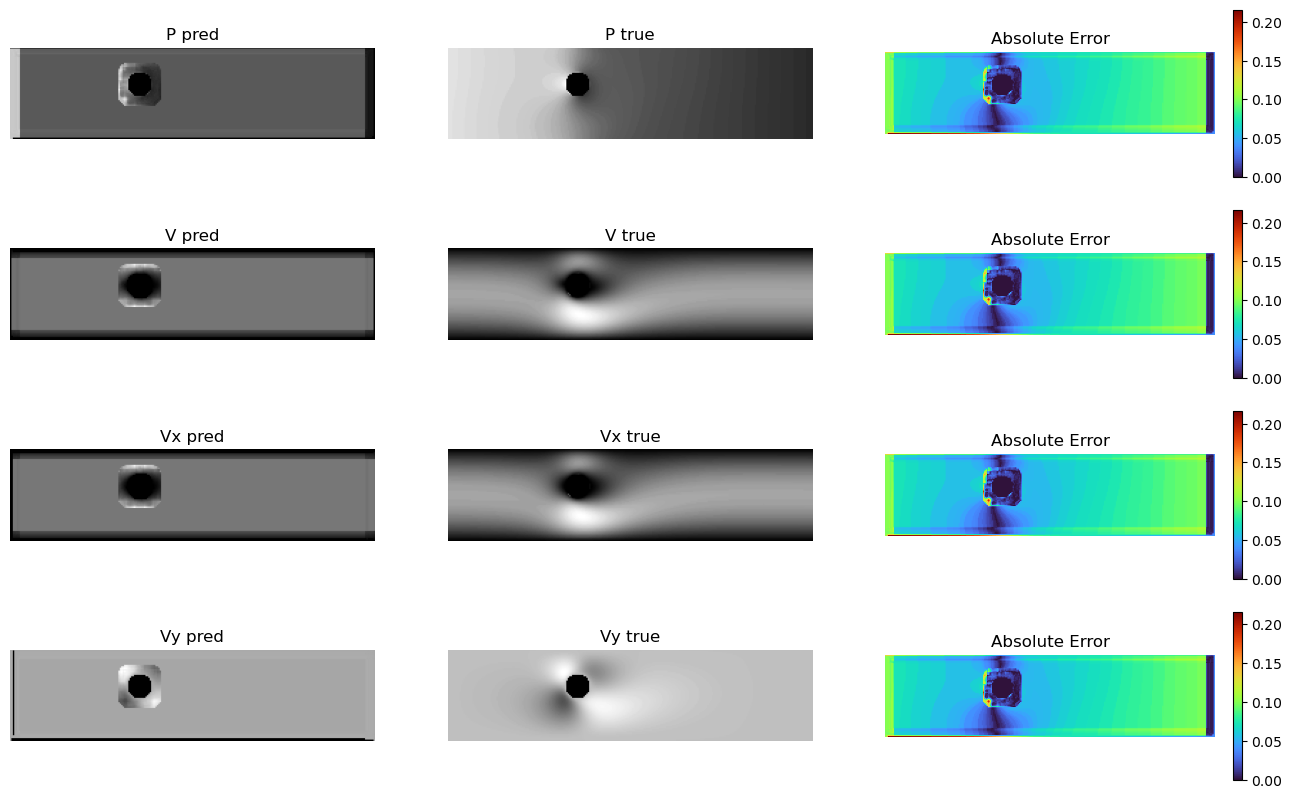

In [20]:
plotting(ytrue,ypred,'visualization_01')

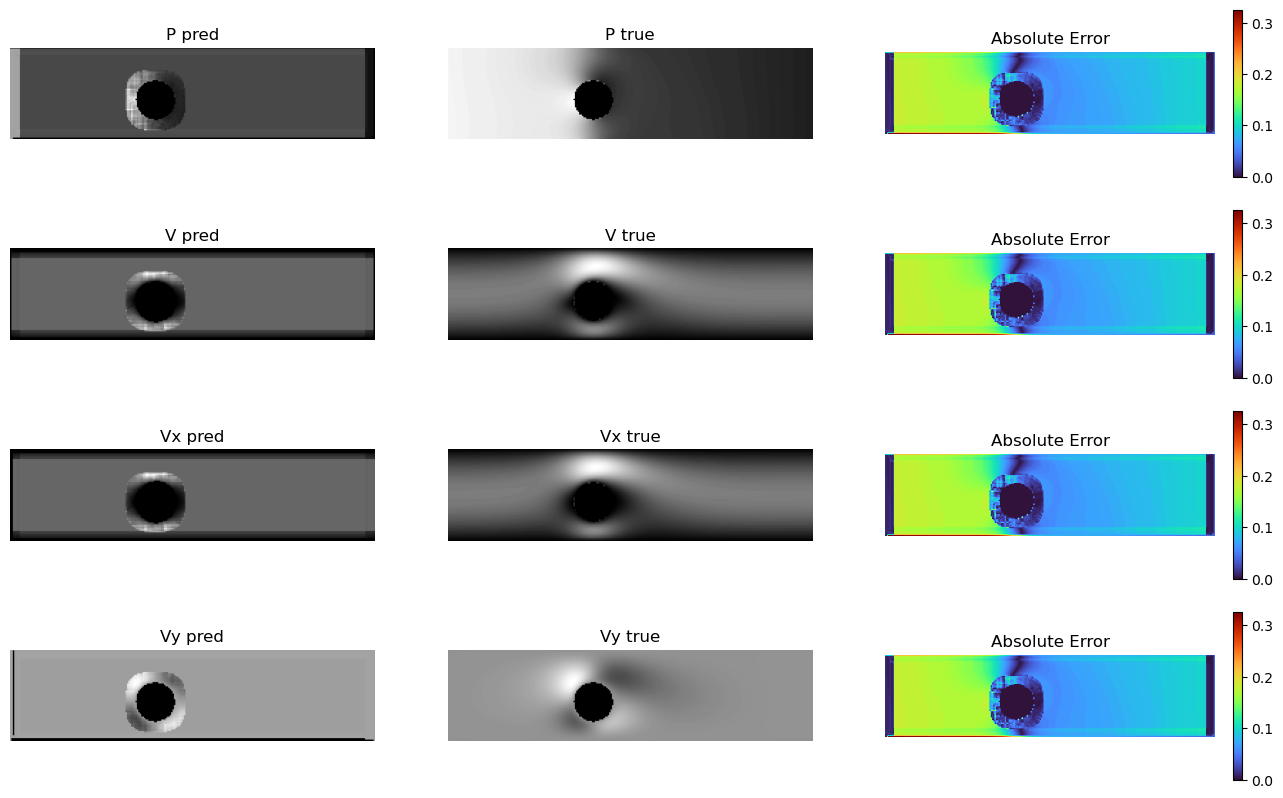

In [21]:
plotting(ytrue,ypred,'visualization_02')

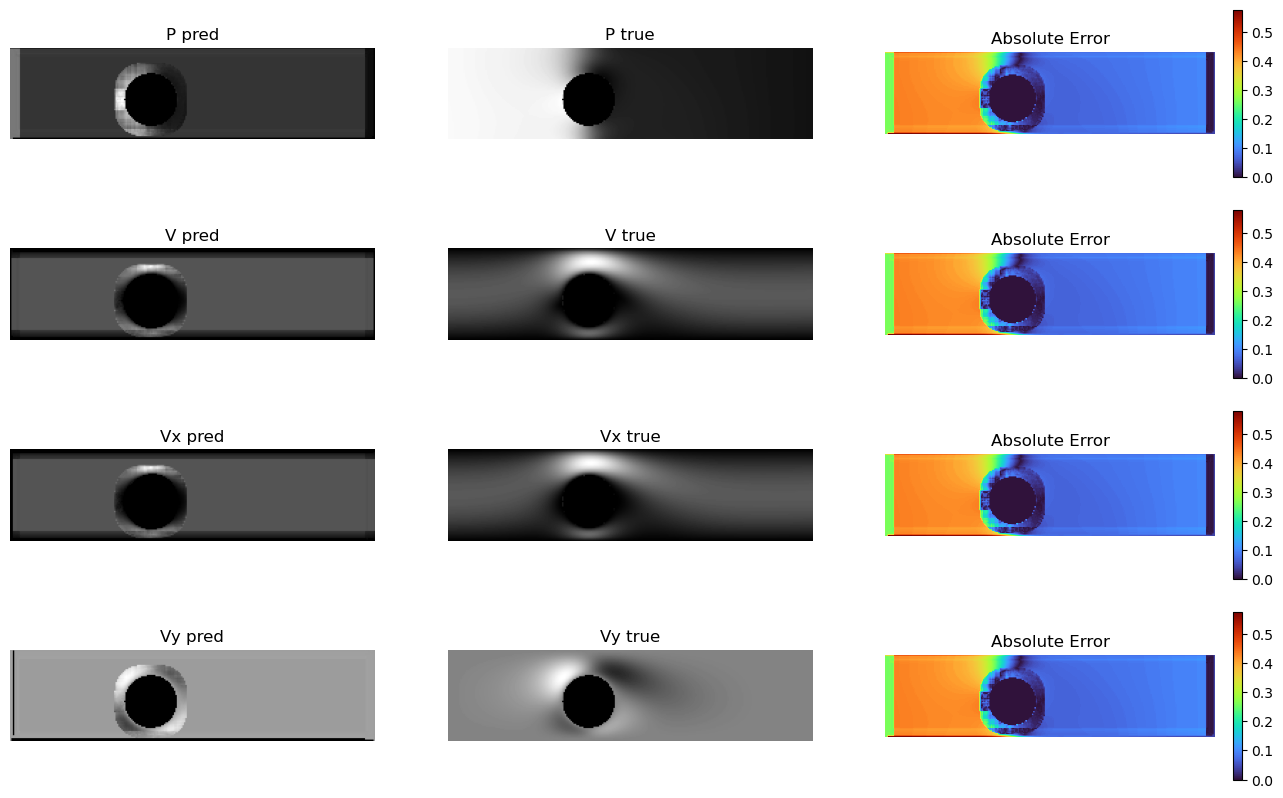

In [22]:
plotting(ytrue,ypred,'visualization_03')

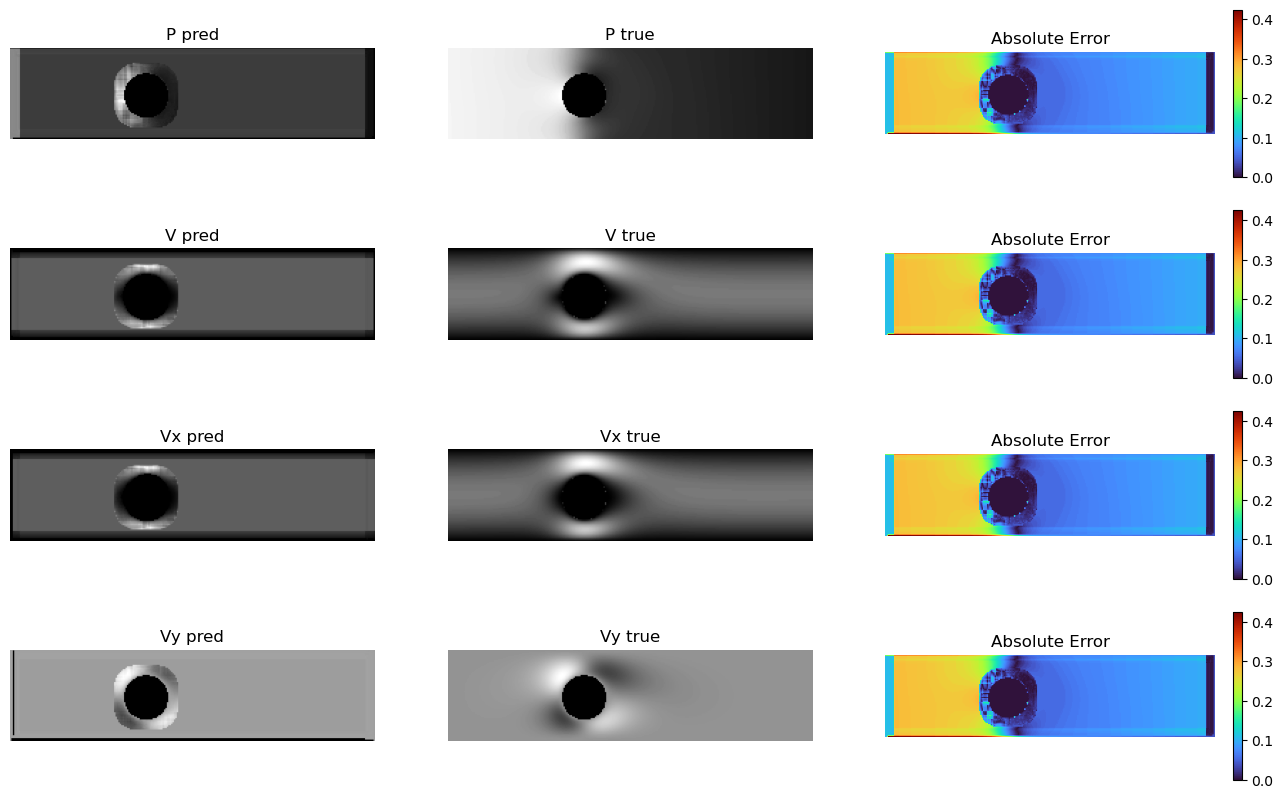

In [23]:
plotting(ytrue,ypred,'visualization_04')